# HELIX Revenue Prediction

## Notebook 05 — Target Leakage Analysis

Objective

Investigate whether any features directly determine the target
variable and should therefore be excluded from production models.

In [1]:
# import library
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

In [2]:
# load dataset
PROJECT_ROOT = Path("..")

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "ecommerce_customer_behavior_dataset_v2.csv"

df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"])

In [3]:
# feature
target = "Total_Amount"

numeric_cols = [
    col for col in df.select_dtypes(include=np.number).columns if col != target
]

categorical_cols = [
    "Gender",
    "City",
    "Product_Category",
    "Payment_Method",
    "Device_Type",
    "Is_Returning_Customer",
]

## Business Question

When should revenue prediction occur?

Scenario A

Before checkout.

Available information:

- Customer
- Product
- Device
- City
- Browsing behavior

Transaction amount is still unknown.

---

Scenario B

After checkout.

Available information:

- Unit Price
- Quantity
- Discount

Revenue can already be calculated mathematically.

Therefore, Scenario A represents a genuine machine learning prediction problem,
whereas Scenario B represents transaction amount estimation.

In [5]:
# mathematical validation
df["Calculated_Total"] = df["Unit_Price"] * df["Quantity"] - df["Discount_Amount"]

df["Difference"] = (df["Calculated_Total"] - df["Total_Amount"]).abs()

df[
    [
        "Unit_Price",
        "Quantity",
        "Discount_Amount",
        "Calculated_Total",
        "Total_Amount",
        "Difference",
    ]
].head()

print("Maximum Error :", df["Difference"].max())

print("Average Error :", df["Difference"].mean())

Maximum Error : 3.637978807091713e-12
Average Error : 4.71712397442402e-14


                 Unit_Price  Quantity  Discount_Amount  Total_Amount
Unit_Price         1.000000 -0.001539         0.477427      0.866225
Quantity          -0.001539  1.000000         0.128507      0.256567
Discount_Amount    0.477427  0.128507         1.000000      0.456245
Total_Amount       0.866225  0.256567         0.456245      1.000000


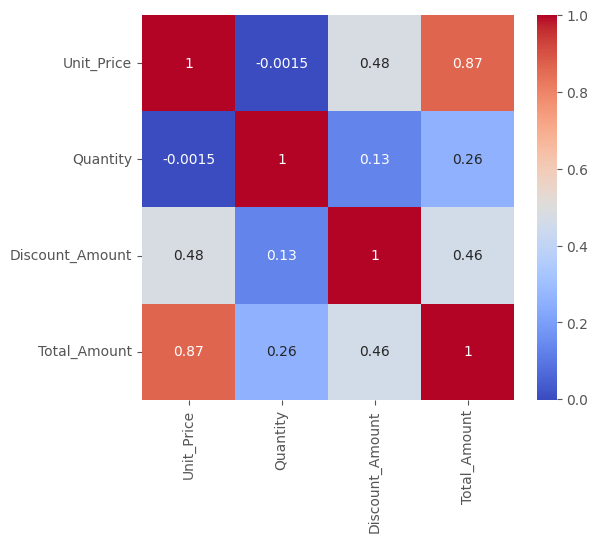

In [7]:
# correlation investigation
corr = df[["Unit_Price", "Quantity", "Discount_Amount", "Total_Amount"]].corr()

print(corr)

plt.figure(figsize=(6, 5))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.show()

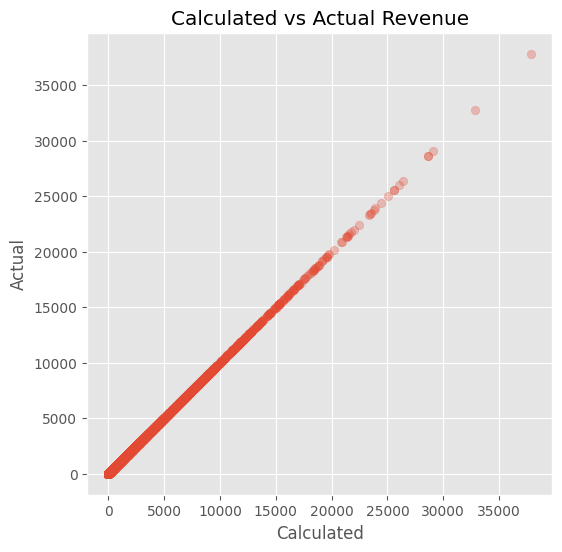

In [8]:
# leakage visualization
plt.figure(figsize=(6, 6))

plt.scatter(df["Calculated_Total"], df["Total_Amount"], alpha=0.3)

plt.xlabel("Calculated")

plt.ylabel("Actual")

plt.title("Calculated vs Actual Revenue")

plt.show()

In [9]:
# feature dependency
dependency = pd.DataFrame(
    {
        "Feature": ["Unit_Price", "Quantity", "Discount_Amount"],
        "Business Dependency": ["Direct", "Direct", "Direct"],
        "Leakage Risk": ["High", "High", "High"],
    }
)

dependency

,Feature,Business Dependency,Leakage Risk
0,Unit_Price,Direct,High
1,Quantity,Direct,High
2,Discount_Amount,Direct,High


In [10]:
# business scenario comparison
comparison = pd.DataFrame(
    {
        "Scenario": ["Business Prediction", "Transaction Estimation"],
        "Use Leakage Features": ["No", "Yes"],
        "Business Value": ["High", "Medium"],
        "Expected Accuracy": ["Moderate", "Very High"],
    }
)

comparison

,Scenario,Use Leakage Features,Business Value,Expected Accuracy
0,Business Prediction,No,High,Moderate
1,Transaction Estimation,Yes,Medium,Very High


In [11]:
# leakage decision matrix
decision = pd.DataFrame(
    {
        "Feature": [
            "Order_ID",
            "Customer_ID",
            "Date",
            "Age",
            "Gender",
            "City",
            "Product_Category",
            "Unit_Price",
            "Quantity",
            "Discount_Amount",
            "Payment_Method",
            "Device_Type",
            "Session_Duration_Minutes",
            "Pages_Viewed",
            "Is_Returning_Customer",
            "Delivery_Time_Days",
            "Customer_Rating",
        ],
        "Decision": [
            "Drop",
            "Drop",
            "Keep",
            "Keep",
            "Keep",
            "Keep",
            "Keep",
            "Drop",
            "Drop",
            "Drop",
            "Keep",
            "Keep",
            "Keep",
            "Keep",
            "Keep",
            "Keep",
            "Keep",
        ],
        "Reason": [
            "Identifier",
            "Identifier",
            "Feature Engineering",
            "Useful",
            "Useful",
            "Useful",
            "Useful",
            "Target Leakage",
            "Target Leakage",
            "Target Leakage",
            "Useful",
            "Useful",
            "Useful",
            "Useful",
            "Useful",
            "Useful",
            "Useful",
        ],
    }
)

decision

,Feature,Decision,Reason
0,Order_ID,Drop,Identifier
1,Customer_ID,Drop,Identifier
2,Date,Keep,Feature Engineering
3,Age,Keep,Useful
4,Gender,Keep,Useful
5,City,Keep,Useful
6,Product_Category,Keep,Useful
7,Unit_Price,Drop,Target Leakage
8,Quantity,Drop,Target Leakage
9,Discount_Amount,Drop,Target Leakage


In [12]:
# recommended features
selected_features = [
    "Date",
    "Age",
    "Gender",
    "City",
    "Product_Category",
    "Payment_Method",
    "Device_Type",
    "Session_Duration_Minutes",
    "Pages_Viewed",
    "Is_Returning_Customer",
    "Delivery_Time_Days",
    "Customer_Rating",
]

selected_features

['Date',
 'Age',
 'Gender',
 'City',
 'Product_Category',
 'Payment_Method',
 'Device_Type',
 'Session_Duration_Minutes',
 'Pages_Viewed',
 'Is_Returning_Customer',
 'Delivery_Time_Days',
 'Customer_Rating']

# Final Strategy

Two models will be developed.

## Model A

Business Prediction

Target

Total_Amount

Drop

- Unit_Price
- Quantity
- Discount_Amount

Purpose

Predict revenue before checkout.

---

## Model B

Transaction Estimation

Include all features.

Purpose

Benchmark only.

Model A will be considered the production model.